In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import healpy as hp
import astropy.io.fits as fits
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import matplotlib.colors as mcolors
import astropy.units as u

In [3]:
beam = 60 * u.arcmin
nside=128

In [4]:
# PR3 Planck Commander CMB map
com_map="COM_CMB_IQU-commander_2048_R3.00_full.fits"
# Convert to mK
com=hp.fitsfunc.read_map(com_map,field=[0])*1000

# Smooth to 1 degree from native resolution
dbeam1 = 60 * u.arcmin
dbeam2 = 5 * u.arcmin
dfwhm = np.sqrt(dbeam1**2-dbeam2**2)
com_smooth = hp.smoothing(com, fwhm=dfwhm.to_value(u.radian))

# Downgrade to NSIDE = 128
com_dg = hp.ud_grade(com_smooth, nside)

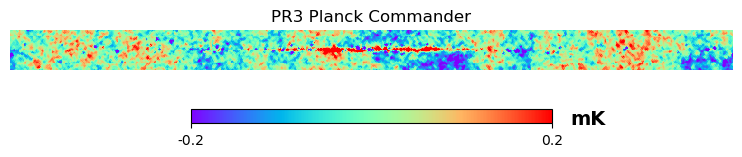

In [5]:
hp.cartview(com_dg, latra = [-10,10], min=-0.2, max=0.2, title = 'PR3 Planck Commander', unit = 'mK', cmap='rainbow')

In [6]:
# Input cleaned maps from initial cleaning fit
initial_70_map="INITIAL_Maps/Initial_70GHz.fits"
initial_70=hp.fitsfunc.read_map(initial_70_map,field=[0])

initial_94_map="INITIAL_Maps/Initial_94GHz.fits"
initial_94=hp.fitsfunc.read_map(initial_94_map,field=[0])

initial_100_map="INITIAL_Maps/Initial_100GHz.fits"
initial_100=hp.fitsfunc.read_map(initial_100_map,field=[0])

initial_143_map="INITIAL_Maps/Initial_143GHz.fits"
initial_143=hp.fitsfunc.read_map(initial_143_map,field=[0])

In [7]:
# Input Sagittarius A mask (description in Section 3.2) 
sgrA="../Masks/sgrA_mask.fits"
sgrA=hp.fitsfunc.read_map(sgrA,field=[0])

In [8]:
# Apply Sagittarius A mask to initial cleaned maps
p70_sgrA = sgrA*initial_70
w94_sgrA = sgrA*initial_94
p100_sgrA = sgrA*initial_100
p143_sgrA = sgrA*initial_143

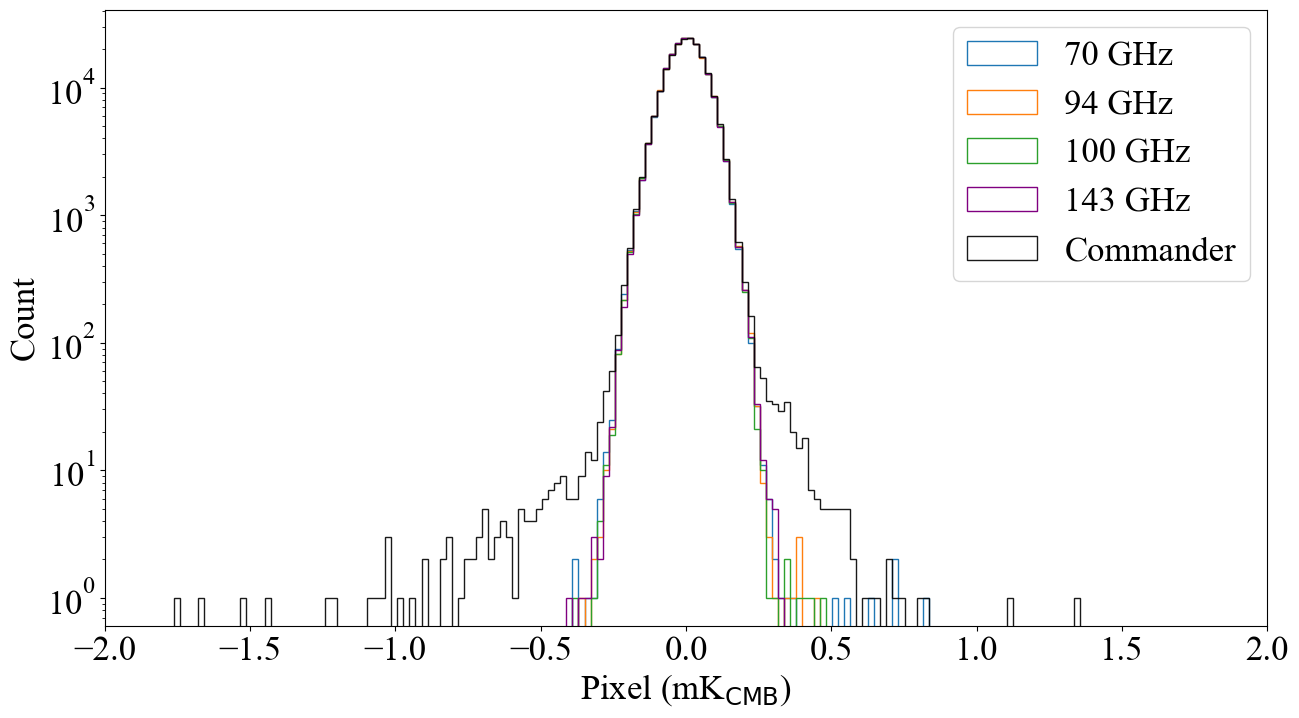

In [9]:
all_data = np.concatenate([p70_sgrA, w94_sgrA, p100_sgrA, p143_sgrA, com_dg])
bin_edges = np.linspace(np.nanmin(all_data), np.nanmax(all_data), 151)

plt.rcParams.update({'font.size': 25})
plt.rcParams['font.family'] = 'Times New Roman'

fig = plt.figure(figsize=(15, 8))
plt.hist(p70_sgrA, histtype='step', label='70 GHz', bins=bin_edges, alpha=1)
plt.hist(w94_sgrA, histtype='step', label='94 GHz', bins=bin_edges, alpha=1)
plt.hist(p100_sgrA, histtype='step', label='100 GHz', bins=bin_edges, alpha=1)
plt.hist(p143_sgrA, histtype='step', label='143 GHz', bins=bin_edges, alpha=1, color='purple')
plt.hist(com_dg, histtype='step', label='Commander', bins=bin_edges, alpha=0.9, color='black')
plt.xlim(-2,2)
plt.yscale('log')
plt.ylabel('Count')
plt.xlabel(r'Pixel (mK$_{\rm CMB}$)')
plt.legend()
plt.show()